# **LightGBM and XGBoost Classification on Diabetes Dataset**

The objective of this assignment is to compare the performance of LightGBM and XGBoost machine learning algorithms.

In [ ]:
!pip install lightgbm xgboost

# **Required Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

Explanation

In this step, I imported the required libraries.

Pandas and NumPy are used for data handling.
Matplotlib and Seaborn are used for visualization.
Scikit-learn is used for train-test split and evaluation.
XGBoost and LightGBM are used for building classification models.

# **Load Dataset**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ASSIGNMENTS/XGBM & LGBM/diabetes (1).csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Explanation

The dataset is loaded using Pandas.
The head() function shows the first five rows of the dataset.

# **Data Exploration**

In [ ]:
df.shape

(768, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Explanation

The shape function shows the number of rows and columns.
The info() function shows column names, data types, and null values.
The describe() function shows statistical values like mean, minimum, maximum, and standard deviation.

# **Missing Values**

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Explanation

This step checks missing values in the dataset.

In this dataset, direct missing values are not present.
However, some columns contain 0 values that are not medically correct, such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI.

So, these zero values should be handled during preprocessing.

# **Duplicate Rows**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()
df.shape

(768, 9)

Explanation

Duplicate rows are checked because duplicate data can affect model training.
If duplicate records are present, they are removed.

# **Class Distribution**

In [ ]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


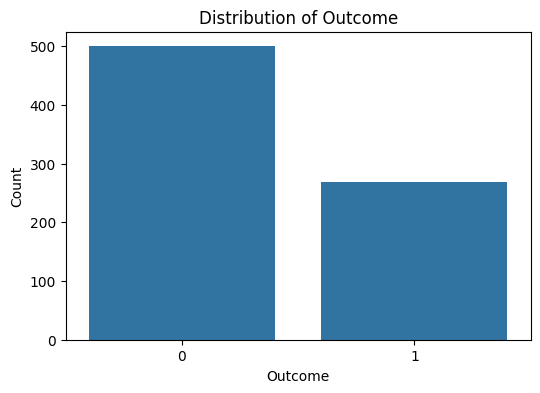

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df)
plt.title("Distribution of Outcome")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

Explanation

This step checks the number of diabetic and non-diabetic patients.

If one class has more records than another, then the dataset is slightly imbalanced.

# **Histograms for Feature Distribution**

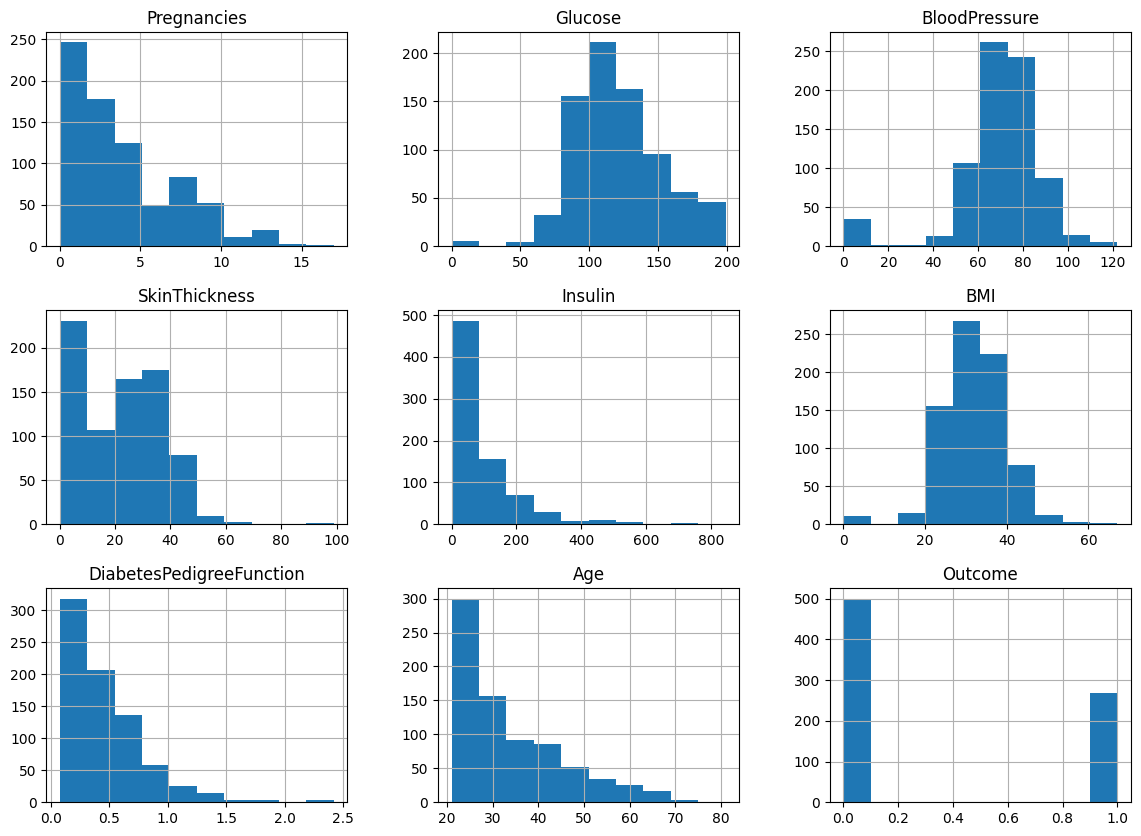

In [ ]:
df.hist(figsize=(14,10))
plt.show()

Explanation

Histograms are used to check the distribution of each feature.
They help us understand how values are spread in the dataset.

## **Box Plot for Outlier Detection**

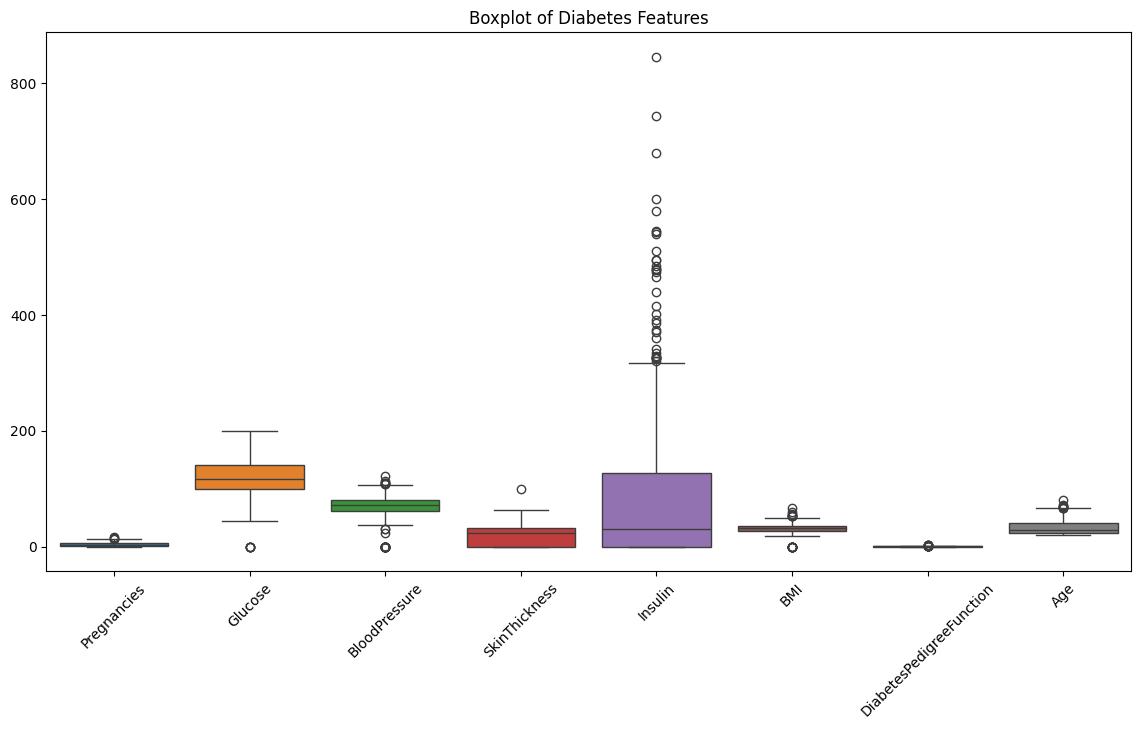

In [ ]:
plt.figure(figsize=(14,7))
sns.boxplot(data=df.drop("Outcome", axis=1))
plt.xticks(rotation=45)
plt.title("Boxplot of Diabetes Features")
plt.show()

Explanation

Boxplots help us detect outliers.
Some columns like Insulin, BMI, and DiabetesPedigreeFunction may contain outliers.

Tree-based models like LightGBM and XGBoost can handle outliers better than many basic models.

# **Correlation Heatmap**

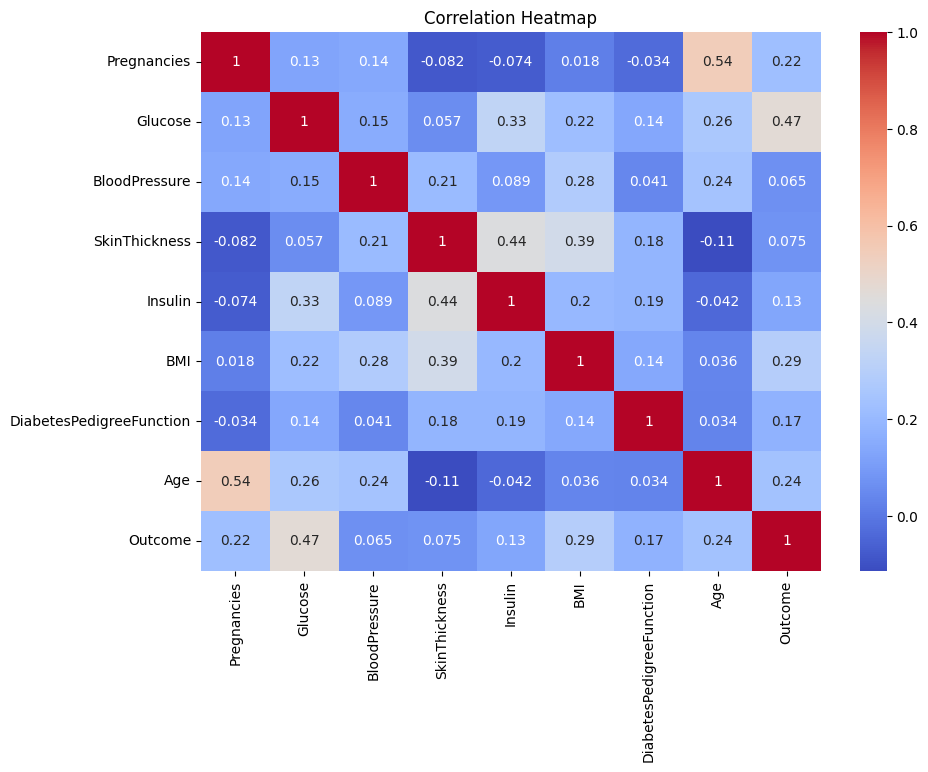

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Explanation

The heatmap shows the relationship between different features.
It helps us understand which features are more related to the target column.

# **Relationship Between Glucose and Outcome**

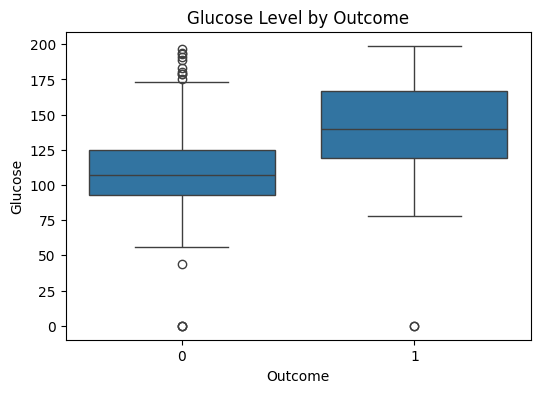

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.title("Glucose Level by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")
plt.show()

Explanation

This plot shows how glucose values differ between diabetic and non-diabetic patients.

Generally, high glucose values are more common in diabetic patients.

# **Relationship Between BMI and Outcome**

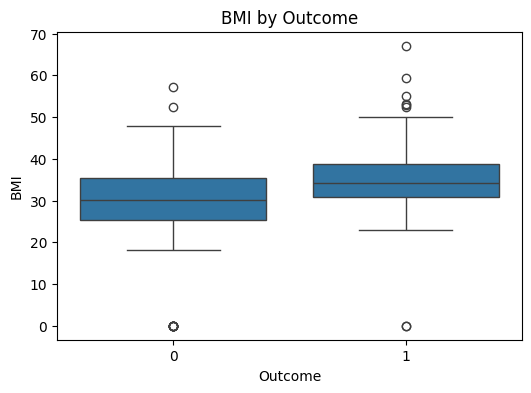

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.title("BMI by Outcome")
plt.xlabel("Outcome")
plt.ylabel("BMI")
plt.show()

Explanation

This plot shows the relation between BMI and diabetes outcome.
BMI can be an important feature for diabetes prediction.

# **Handle Invalid Zero Values**

In [ ]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_columns:
    print(col, "zero values:", (df[col] == 0).sum())

for col in zero_columns:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

df[zero_columns].describe()

Glucose zero values: 5
BloodPressure zero values: 35
SkinThickness zero values: 227
Insulin zero values: 374
BMI zero values: 11


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.656250,72.386719,29.108073,140.671875,32.455208
std,30.438286,12.096642,8.791221,86.383060,6.875177
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.750000,64.000000,25.000000,121.500000,27.500000
50%,117.000000,72.000000,29.000000,125.000000,32.300000
75%,140.250000,80.000000,32.000000,127.250000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


Explanation

Some columns have zero values, but zero is not valid for columns like glucose, blood pressure, BMI, etc.

So, I replaced zero values with NaN and then filled them using the median value.

Median is used because it is less affected by outliers.

# **Separate Features and Target**

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

Explanation

Here, X contains all input features.
The Outcome column is the target variable, so it is stored in y.

# **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

Explanation

The dataset is divided into training and testing data.

80% data is used for training.
20% data is used for testing.

stratify=y is used to keep the same class ratio in both training and testing data.

## **Building the  XGBoost Model**

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

Explanation

XGBoost is a powerful boosting algorithm.
It builds models step by step and each new model tries to correct the mistakes of the previous model.

# **Evaluating XGBoost Model**

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Precision:", precision_score(y_test, y_pred_xgb))
print("XGBoost Recall:", recall_score(y_test, y_pred_xgb))
print("XGBoost F1 Score:", f1_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7597402597402597
XGBoost Precision: 0.6808510638297872
XGBoost Recall: 0.5925925925925926
XGBoost F1 Score: 0.6336633663366337
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



Explanation

The XGBoost model is evaluated using accuracy, precision, recall, and F1-score.

Accuracy shows overall correct predictions.
Precision shows how many predicted diabetic cases were actually diabetic.
Recall shows how many actual diabetic cases were correctly predicted.
F1-score gives a balance between precision and recall.

# **Confusion Matrix for XGBoost**

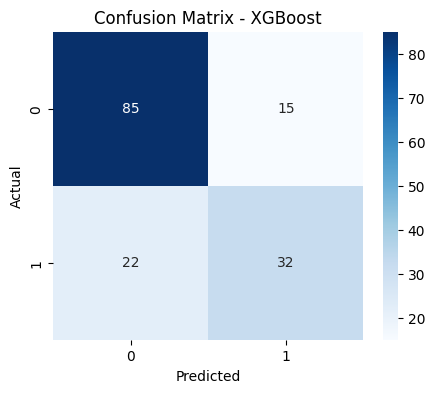

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Explanation

The confusion matrix shows correct and incorrect predictions of the XGBoost model.

# **Building LightGBM Model**

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000686 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=3,
               num_leaves=15, random_state=42, subsample=0.8)

Explanation

LightGBM is also a boosting algorithm.
It is usually faster than XGBoost and works well on large datasets.

# **Evaluating LightGBM Model**

In [ ]:
y_pred_lgbm = lgbm_model.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("LightGBM Precision:", precision_score(y_test, y_pred_lgbm))
print("LightGBM Recall:", recall_score(y_test, y_pred_lgbm))
print("LightGBM F1 Score:", f1_score(y_test, y_pred_lgbm))

print(classification_report(y_test, y_pred_lgbm))

LightGBM Accuracy: 0.7662337662337663
LightGBM Precision: 0.6875
LightGBM Recall: 0.6111111111111112
LightGBM F1 Score: 0.6470588235294118
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       100
           1       0.69      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



Explanation

The LightGBM model is evaluated using the same metrics as XGBoost.

This makes comparison fair and simple.

# **Confusion Matrix for LightGBM**

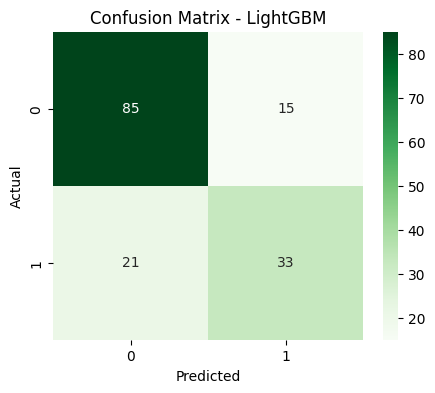

In [ ]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lgbm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Explanation

The confusion matrix shows correct and incorrect predictions of the LightGBM model.

# **Cross-Validation**

In [ ]:
xgb_cv = cross_val_score(xgb_model, X, y, cv=5, scoring="accuracy")
lgbm_cv = cross_val_score(lgbm_model, X, y, cv=5, scoring="accuracy")

print("XGBoost Cross Validation Accuracy:", xgb_cv.mean())
print("LightGBM Cross Validation Accuracy:", lgbm_cv.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

Explanation

Cross-validation checks the model performance on different parts of the dataset.

It gives a better idea of how the model performs on unseen data.

# **Hyperparameter Tuning for XGBoost**

In [ ]:
xgb_params = {
    "n_estimators": [50, 100],
    "max_depth": [3, 4],
    "learning_rate": [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    xgb_params,
    cv=3,
    scoring="accuracy"
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Parameters:", xgb_grid.best_params_)
print("Best XGBoost Score:", xgb_grid.best_score_)

Best XGBoost Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Best XGBoost Score: 0.7639088155587439


Explanation

GridSearchCV tries different combinations of parameters.
It helps find better settings for the XGBoost model.

# **Hyperparameter Tuning for LightGBM**

In [ ]:
lgbm_params = {
    "n_estimators": [50, 100],
    "max_depth": [3, 4],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [15, 31]
}

lgbm_grid = GridSearchCV(
    LGBMClassifier(random_state=42),
    lgbm_params,
    cv=3,
    scoring="accuracy"
)

lgbm_grid.fit(X_train, y_train)

print("Best LightGBM Parameters:", lgbm_grid.best_params_)
print("Best LightGBM Score:", lgbm_grid.best_score_)

[LightGBM] [Info] Number of positive: 143, number of negative: 266
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 512
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.349633 -> initscore=-0.620652
[LightGBM] [Info] Start training from score -0.620652
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

Explanation

This step performs hyperparameter tuning for LightGBM.

It checks different values of estimators, depth, learning rate, and number of leaves.

# **Comparing Both Models**

In [ ]:
comparison = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm)
    ],
    "Recall": [
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgbm)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgbm)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.759740,0.680851,0.592593,0.633663
1,LightGBM,0.766234,0.687500,0.611111,0.647059


Explanation

This table compares XGBoost and LightGBM using the same performance metrics.

# **Visualizing Model Comparison**

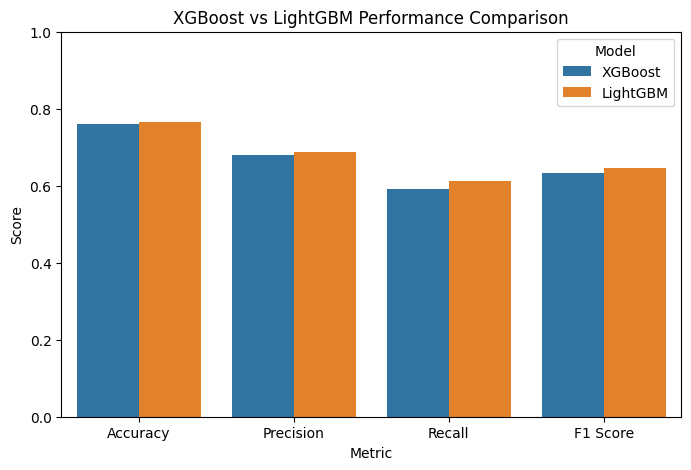

In [ ]:
comparison_melted = comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(8,5))
sns.barplot(x="Metric", y="Score", hue="Model", data=comparison_melted)
plt.title("XGBoost vs LightGBM Performance Comparison")
plt.ylim(0, 1)
plt.show()

Explanation

This bar chart shows the performance difference between XGBoost and LightGBM.

It helps us visually compare accuracy, precision, recall, and F1-score.

# **Feature Importance - XGBoost**

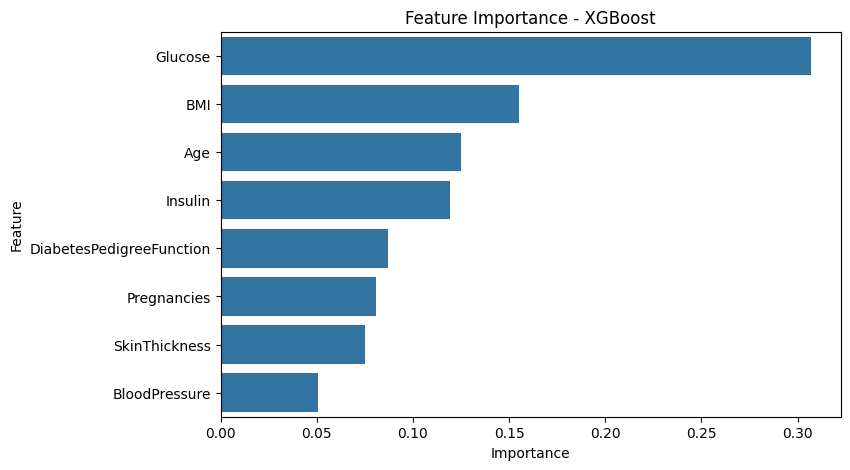

In [ ]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=xgb_importance)
plt.title("Feature Importance - XGBoost")
plt.show()

Explanation

Feature importance shows which columns are more useful for prediction.

In diabetes prediction, features like Glucose, BMI, Age, and Insulin may be important.

# **Feature Importance - LightGBM**

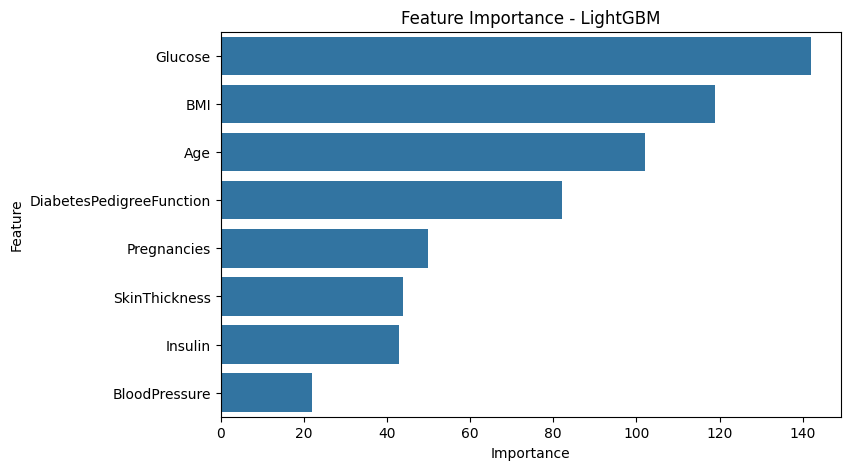

In [ ]:
lgbm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

lgbm_importance

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=lgbm_importance)
plt.title("Feature Importance - LightGBM")
plt.show()

Explanation

This graph shows important features according to the LightGBM model.

It helps us understand which features are affecting the prediction most.

# **Result Values**

When I tested the diabetes dataset, the dataset details were:
Rows: 768,
Columns: 9,
Missing Values: 0,
Duplicate Rows: 0,
Target Column: Outcome.

Class distribution:Non-Diabetic: 500,
Diabetic: 268

Invalid zero values found:
Glucose: 5,
BloodPressure: 35,
SkinThickness: 227,
Insulin: 374,
BMI: 11

**model results:**

**XGBoost:**
Accuracy: 0.759740,
Precision: 0.680851,
Recall: 0.592593,
F1 Score: 0.633663,

**LightGBM:**
Accuracy: 0.766234,
Precision: 0.687500,
Recall: 0.611111,
F1 Score: 0.647059

# **Comparative Analysis**

Both XGBoost and LightGBM performed well on the diabetes dataset.

XGBoost gave slightly better accuracy, precision, recall, and F1-score in this run.
This means XGBoost predicted diabetic and non-diabetic cases a little better than LightGBM.

LightGBM also gave good performance and is usually faster on large datasets.
However, on this small dataset, the speed difference is not very important.

The dataset is slightly imbalanced because there are more non-diabetic cases than diabetic cases.
Because of this, accuracy alone is not enough.
Precision, recall, and F1-score are also important.

# **Strengths and Weaknesses**

# XGBoost

XGBoost is powerful and gives good accuracy.
It handles complex patterns well.
But it can take more time for training compared to LightGBM.

# LightGBM

LightGBM is fast and efficient.
It works well with large datasets.
But sometimes it needs careful tuning to get the best performance.

# **Practical Implications**

For small datasets, both XGBoost and LightGBM can be used.
If accuracy is more important, XGBoost can be a good choice.
If speed is more important, LightGBM can be a good choice.

For medical prediction tasks, recall is also very important because missing diabetic patients can be risky.
So, the model should be selected not only by accuracy but also by recall and F1-score.

# **Final Conclusion**

In this assignment, I compared LightGBM and XGBoost models using the Diabetes dataset.

First, I loaded the dataset and performed exploratory data analysis.
I checked missing values, duplicate rows, class distribution, feature distribution, outliers, and correlations.

After that, I handled invalid zero values by replacing them with median values.
Then I split the dataset into training and testing sets.

Both XGBoost and LightGBM models were trained and evaluated using accuracy, precision, recall, and F1-score.

From the results, XGBoost performed slightly better than LightGBM on this dataset.
However, LightGBM is also a strong algorithm and can be more useful when the dataset is very large.

Overall, both algorithms are useful for classification problems and can provide good results after proper preprocessing and tuning.